# Calibration of the pixel position for a Pilatus detector

This tutorial summarizes the work done by Frederic Sulzman during his internship at ESRF during the summer 2015 entitled "Calibration for geometric distortion in multi-
modules pixel detectors".

The overall strategy is very similar to "CCD calibration" tutorial with some specificities due to the modular nature of the detector.

0. Image preprocessing
1. Peak picking
2. Grid assignment
3. Displacement fitting
4. Reconstruction of the pixel position
5. Saving into a detector definition file
6. Validation of the geometry with a 2D integration

Each module being made by lithographic processes, the error within a module will be assumed to be constant. We will use the name "displacement of the module" to describe the rigid movement of the module.

This tutorial uses data from the Pilatus3 2M CdTe from the ID15 beam line of the ESRF. 
They provided not only the internship subject but also the couple of images used to calibrate the detector.

This detector contains 48 half-modules, each bound to a single CdTe monocrystal sensor and is designed for high energy X-ray radiation detection. 
Due to the construction procedure, these half-modules could show a misalignment within the detector
plane. 
While the manufacturer (Dectris) guarantees a precision within a pixel (172µm), the misalignment of certain modules can be seen while calibrating Debye-Scherrer ring using a reference sample. 
So the aim of this work is to provide a detector description with a better precision than the original detector.

This work will be performed on the image of a grid available:
http://www.silx.org/pub/pyFAI/detector_calibration/Pilatus2MCdTe_ID15_grid_plus_sample_0004.cbf
and the scattering of ceria (CeO2) at 72.1keV available here.
http://www.silx.org/pub/pyFAI/detector_calibration/Pilatus2MCdTe_ID15_CeO2_72100eV_800mm_0000.cbf

It is a good exercise to calibrate all rings of the latter image using the *pyFAI-calib2* tool. 
A calibration close to perfection is needed to visualize the module misalignment we aim at correcting.

In [1]:
%matplotlib inline 
#For documentation purpose, `inline` is used to enforce the storage of the image in the notebook
#matplotlib widget
#many imports which will be used all along the notebook
import time
start_time = time.perf_counter()
import os
import pyFAI
import fabio
import glob
import numpy
from numpy.lib.stride_tricks import as_strided
from math import sin, cos, sqrt
import scipy
from scipy.ndimage import convolve, binary_dilation
from scipy.optimize import minimize
from matplotlib.pyplot import subplots
from pyFAI.ext.bilinear import Bilinear
from pyFAI.ext.watershed import InverseWatershed
from silx.resources import ExternalResources
from pyFAI.integrator.azimuthal import AzimuthalIntegrator
if scipy.__version__ >= "0.18":
    from scipy.spatial.distance  import cdist as distance_matrix
else:    
    from scipy.spatial import distance_matrix

print("Using pyFAI verison: ", pyFAI.version)

Using pyFAI verison:  2026.6.0-dev0


In [2]:
# A couple of compound dtypes ...
dt = numpy.dtype([('y', numpy.float64),
                  ('x', numpy.float64),
                  ('i', numpy.int64),
                 ])
dl = numpy.dtype([('y', numpy.float64),
                  ('x', numpy.float64),
                  ('i', numpy.int64),
                  ('Y', numpy.int64),
                  ('X', numpy.int64),
                 ])


In [3]:
#Nota: Configure here your proxy if you are behind a firewall
#os.environ["http_proxy"] = "http://proxy.comany.com:3128"

In [4]:
downloader = ExternalResources("detector_calibration", "http://www.silx.org/pub/pyFAI/detector_calibration/")
ring_file = downloader.getfile("Pilatus2MCdTe_ID15_CeO2_72100eV_800mm_0000.cbf")
print(ring_file)
grid_file = downloader.getfile("Pilatus2MCdTe_ID15_grid_plus_sample_0004.cbf")
print(grid_file)

/tmp/detector_calibration_testdata_kieffer/Pilatus2MCdTe_ID15_CeO2_72100eV_800mm_0000.cbf
/tmp/detector_calibration_testdata_kieffer/Pilatus2MCdTe_ID15_grid_plus_sample_0004.cbf


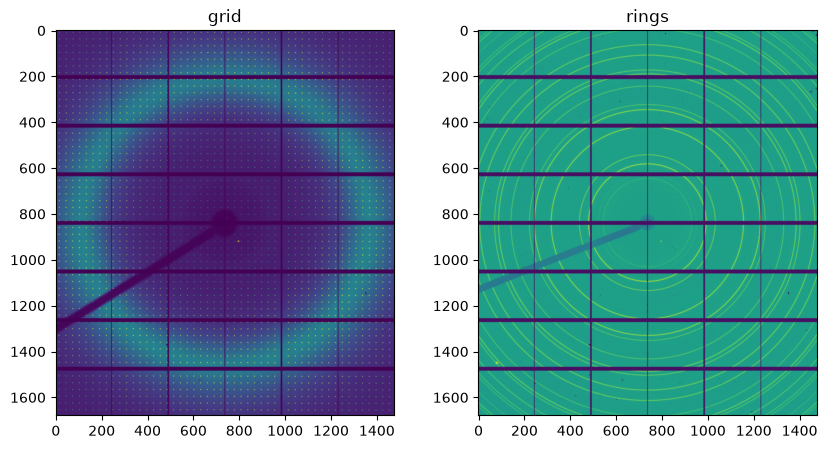

In [5]:
rings = fabio.open(ring_file).data
img = fabio.open(grid_file).data
fig,ax = subplots(1,2, figsize=(10,5))
ax[0].imshow(img.clip(0,1000), interpolation="bilinear")
ax[0].set_title("grid")
ax[1].imshow(numpy.arcsinh(rings), interpolation="bilinear")
ax[1].set_title("rings");

## Image processing

There are 3 pre-processing steps which are needed.

1. Define for each module a unique identifier which will be used later on during the fitting procedure
2. Define the proper mask: each module is the assembly of 4x2 sub-modules and there are (3) interpolated pixels between each sub-module, such "unreliable" pixels should be masked out as well
3. Correct the grid image by the smoothed image to have a constant background.
4. Convolve the raw image with a typical hole shape to allow a precise spotting of the hole center.

In [6]:
# This is the default detector as definied in pyFAI according to the specification provided by Dectris:
pilatus = pyFAI.detector_factory("Pilatus_2m_CdTe")
print(pilatus)

mask1 = pilatus.mask
module_size = pilatus.MODULE_SIZE
module_gap = pilatus.MODULE_GAP
submodule_size = (96,60)

Detector Pilatus CdTe 2M	 PixelSize= 172µm, 172µm	 BottomRight (3)


In [7]:
#1 + 2 Calculation of the module_id and the interpolated-mask:
mid = numpy.zeros(pilatus.shape, dtype=int)
mask2 = numpy.zeros(pilatus.shape, dtype=int)
idx = 1
for i in range(8):
    y_start = i*(module_gap[0] + module_size[0])
    y_stop = y_start + module_size[0]
    for j in range(3):
        x_start = j*(module_gap[1] + module_size[1])
        x_stop = x_start + module_size[1]
        mid[y_start:y_stop,x_start: x_start+module_size[1]//2] = idx
        idx+=1
        mid[y_start:y_stop,x_start+module_size[1]//2: x_stop] = idx
        idx+=1
        mask2[y_start+submodule_size[0]-1:y_start+submodule_size[0]+2,
              x_start:x_stop] = 1
        for k in range(1,8):
            mask2[y_start:y_stop,
              x_start+k*(submodule_size[1]+1)-1:x_start+k*(submodule_size[1]+1)+2] = 1

In [8]:
#Extra masking
mask0 = img<0
#Those pixel are miss-behaving... they are the hot pixels next to the beam-stop
mask0[915:922,793:800] = 1
mask0[817:820,747:750] = 1

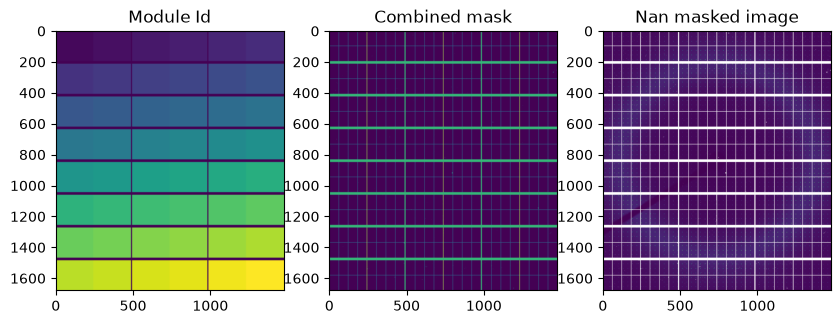

In [9]:
fig,ax = subplots(1,3, figsize=(10,4))
ax[0].imshow(mid, interpolation="bilinear")
ax[0].set_title("Module Id")

ax[1].imshow(mask2+mask1+mask0, interpolation="bilinear")
ax[1].set_title("Combined mask")

nimg = img.astype(float)
nimg[numpy.where(mask0+mask1+mask2)] = numpy.nan


ax[2].imshow(nimg)#, interpolation="bilinear")
ax[2].set_title("Nan masked image");

In [10]:
# The Nan-masked image contains now only valid values (and Nan elsewhere). We will make a large median filter to 
# build up a smooth image without gaps.
#
# This function is backported from future version of numpy ... it allows to expose a winbowed view 
# to perform the nanmedian-filter

def sliding_window_view(x, shape, subok=False, readonly=True):
    """
    Creates sliding window views of the N dimensional array with the given window
    shape. Window slides across each dimension of `x` and extract subsets of `x`
    at any window position.
    Parameters
    ----------
    x : array_like
        Array to create sliding window views of.
    shape : sequence of int
        The shape of the window. Must have same length as the number of input array dimensions.
    subok : bool, optional
        If True, then sub-classes will be passed-through, otherwise the returned
        array will be forced to be a base-class array (default).
    readonly : bool, optional
        If set to True, the returned array will always be readonly view.
        Otherwise it will return writable copies(see Notes).
    Returns
    -------
    view : ndarray
        Sliding window views (or copies) of `x`. view.shape = x.shape - shape + 1
    See also
    --------
    as_strided: Create a view into the array with the given shape and strides.
    broadcast_to: broadcast an array to a given shape.
    Notes
    -----
    ``sliding_window_view`` create sliding window views of the N dimensions array
    with the given window shape and its implementation based on ``as_strided``.
    Please note that if readonly set to True, views are returned, not copies
    of array. In this case, write operations could be unpredictable, so the returned
    views are readonly. Bear in mind that returned copies (readonly=False) will
    take more memory than the original array, due to overlapping windows.
    For some cases there may be more efficient approaches to calculate transformations
    across multi-dimensional arrays, for instance `scipy.signal.fftconvolve`, where combining
    the iterating step with the calculation itself while storing partial results can result
    in significant speedups.
    Examples
    --------
    >>> i, j = np.ogrid[:3,:4]
    >>> x = 10*i + j
    >>> shape = (2,2)
    >>> np.lib.stride_tricks.sliding_window_view(x, shape)
    array([[[[ 0,  1],
             [10, 11]],
            [[ 1,  2],
             [11, 12]],
            [[ 2,  3],
             [12, 13]]],
           [[[10, 11],
             [20, 21]],
            [[11, 12],
             [21, 22]],
            [[12, 13],
             [22, 23]]]])
    """
    np = numpy
    # first convert input to array, possibly keeping subclass
    x = np.array(x, copy=False, subok=subok)

    try:
        shape = np.array(shape, dtype=np.int64)
    except:
        raise TypeError('`shape` must be a sequence of integer')
    else:
        if shape.ndim > 1:
            raise ValueError('`shape` must be one-dimensional sequence of integer')
        if len(x.shape) != len(shape):
            raise ValueError("`shape` length doesn't match with input array dimensions")
        if np.any(shape <= 0):
            raise ValueError('`shape` cannot contain non-positive value')

    o = np.array(x.shape) - shape  + 1 # output shape
    if np.any(o <= 0):
        raise ValueError('window shape cannot larger than input array shape')

    if type(readonly) != bool:
        raise TypeError('readonly must be a boolean')

    strides = x.strides
    view_strides = strides

    view_shape = np.concatenate((o, shape), axis=0)
    view_strides = np.concatenate((view_strides, strides), axis=0)
    view = as_strided(x, view_shape, view_strides, subok=subok, writeable=not readonly)

    if not readonly:
        return view.copy()
    else:
        return view

(1679, 1475)
(1697, 1485)
(1679, 1475)
CPU times: user 12.2 s, sys: 1.93 s, total: 14.1 s
Wall time: 14.1 s


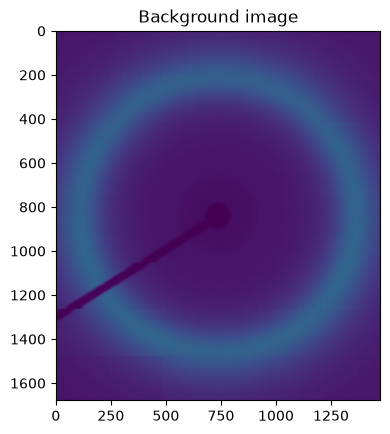

In [11]:
%%time 
#Calculate a background image using a large median filter ... takes a while
shape = (19,11)
print(nimg.shape)
padded = numpy.pad(nimg, tuple((i//2,) for i in shape), mode="edge")
print(padded.shape)
background = numpy.nanmedian(sliding_window_view(padded, shape), axis = (-2,-1))
print(background.shape)
fig,ax = subplots()
ax.imshow(background)
ax.set_title("Background image")
pass

0.0 17.728813559322035


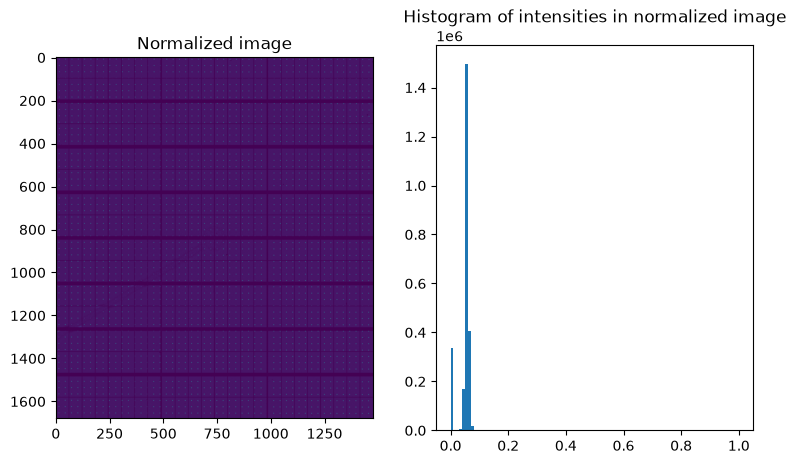

In [12]:
fig,ax = subplots(1,2, figsize=(9,5))

normalized = (nimg/background)

low = numpy.nanmin(normalized)
high = numpy.nanmax(normalized)
print(low, high)
normalized[numpy.isnan(normalized)] = 0
normalized /= high

ax[0].imshow(normalized)
ax[0].set_title("Normalized image")

ax[1].hist(normalized.ravel(), 100, range=(0,1))
ax[1].set_title("Histogram of intensities in normalized image")
pass

For a precise measurement of the peak position, one trick is to convolve the image with a pattern which looks like a hole of the grid.


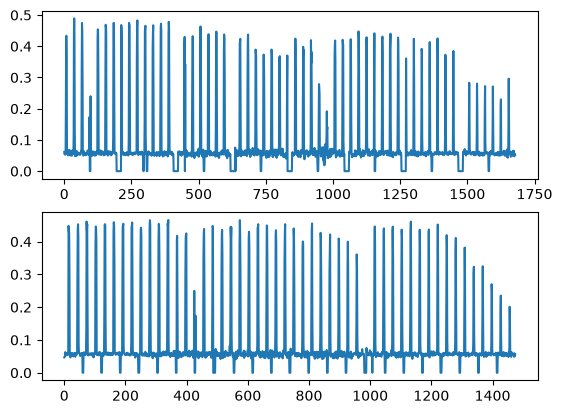

In [13]:
#print the profile of the normalized image: the center is difficult to measure due to the small size of the hole.
fig,ax = subplots(2)
ax[0].plot(normalized[:,545])
ax[1].plot(normalized[536,:])
pass

19.63857792789662


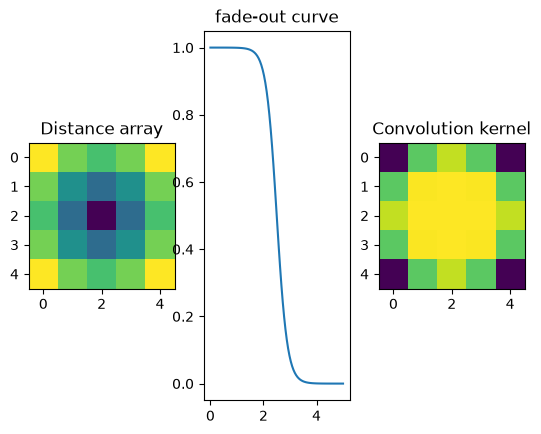

In [14]:
#Definition of the convolution kernel
ksize = 5
y,x = numpy.ogrid[-(ksize-1)//2:ksize//2+1,-(ksize-1)//2:ksize//2+1]
d = numpy.sqrt(y*y+x*x)

#Fade out curve definition
fadeout = lambda x: 1/(1+numpy.exp(5*(x-2.5)))

kernel = fadeout(d)
mini=kernel.sum()
print(mini)

fig,ax = subplots(1,3)
ax[0].imshow(d)
ax[0].set_title("Distance array")

ax[1].plot(numpy.linspace(0,5,100),fadeout(numpy.linspace(0,5,100)))
ax[1].set_title("fade-out curve")

ax[2].imshow(kernel)
ax[2].set_title("Convolution kernel")
pass

(1679, 1475)


(array([1065]), array([338]))

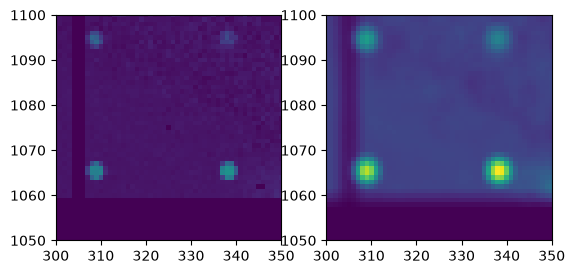

In [15]:
my_smooth = convolve(normalized, kernel, mode="constant", cval=0)/mini
print(my_smooth.shape)
fig,ax = subplots(1,2)
ax[0].imshow(normalized.clip(0,1))
ax[0].set_ylim(1050,1100)
ax[0].set_xlim(300,350)
ax[1].imshow(my_smooth.clip(0,1))
ax[1].set_ylim(1050,1100)
ax[1].set_xlim(300,350)
numpy.where(my_smooth == my_smooth.max())

335009
782371


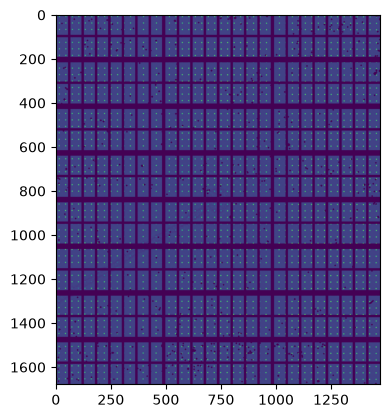

In [16]:
#mask out all pixels too close to any masked position

all_masks = numpy.logical_or(numpy.logical_or(mask0,mask1),mask2)
print(all_masks.sum())
big_mask = binary_dilation(all_masks, iterations=ksize//2+1+1)
print(big_mask.sum())
smooth2 = my_smooth.copy()
smooth2[big_mask] = 0
fig,ax = subplots()
ax.imshow(smooth2)
pass

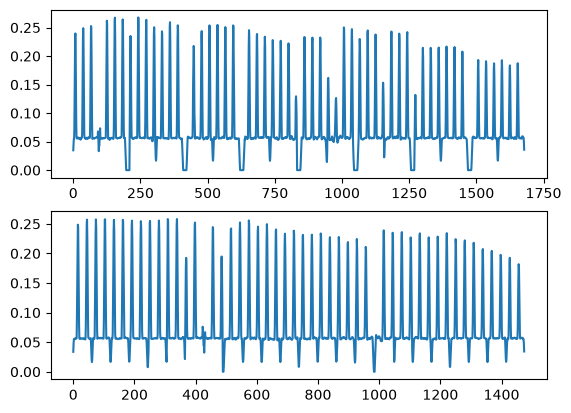

In [17]:
#Display the profile of the smoothed image: the center is easy to measure thanks to the smoothness of the signal
fig,ax = subplots(2)
ax[0].plot(my_smooth[:,545])
ax[1].plot(my_smooth[536,:])
pass

## Peak picking

We use the watershed module from *pyFAI* to retrieve all peak positions.
Those regions are sieved out respectively for:

* their size, it should be larger than the kernel itself
* the peaks too close to masked regions are removed
* the intensity of the peak



In [18]:
iw = InverseWatershed(my_smooth)
iw.init()
iw.merge_singleton()
all_regions = set(iw.regions.values())

regions = [i for i in all_regions if i.size>mini]

print("Number of region segmented: %s"%len(all_regions))
print("Number of large enough regions : %s"%len(regions))

Number of region segmented: 82126
Number of large enough regions : 41333


In [19]:
#Remove peaks on masked region
sieved_region = [i for i in regions if not big_mask[(i.index//nimg.shape[-1], i.index%nimg.shape[-1])]]
print("Number of peaks not on masked areea : %s"%len(sieved_region))

Number of peaks not on masked areea : 30001


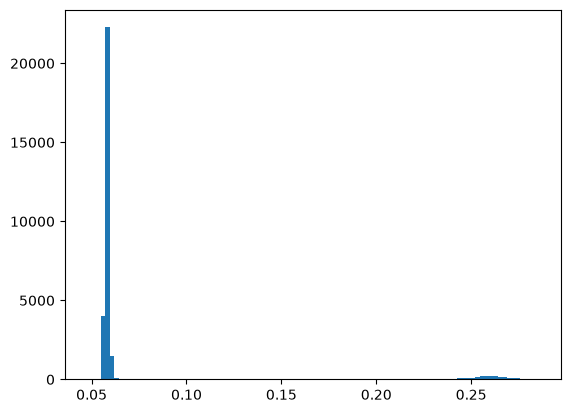

In [20]:
# Histogram of peak height:
s = numpy.array([i.maxi for i in sieved_region])

fig, ax = subplots()
ax.hist(s, 100);

In [21]:
#sieve-out for peak intensity
int_mini = 0.1
peaks = [(i.index//nimg.shape[-1], i.index%nimg.shape[-1]) for i in sieved_region if (i.maxi)>int_mini]
print("Number of remaining peaks with I>%s: %s"%(int_mini, len(peaks)))

peaks_raw = numpy.array(peaks)

Number of remaining peaks with I>0.1: 2075


Refined peak coordinate:
[(1036.3386381268501, 337.9492468163371), (1564.752514153719, 14.56304681301117), (1564.8798207268119, 43.73962017893791), (1564.9691660422832, 73.27792963385582), (1564.9451799243689, 102.48229992389679), (1565.1218742132187, 132.01769062317908), (1565.1106412187219, 161.49520683288574), (1565.2279402315617, 190.76831930875778), (1565.2469960451126, 220.2945808172226), (1565.2476566582918, 249.60243299603462)]


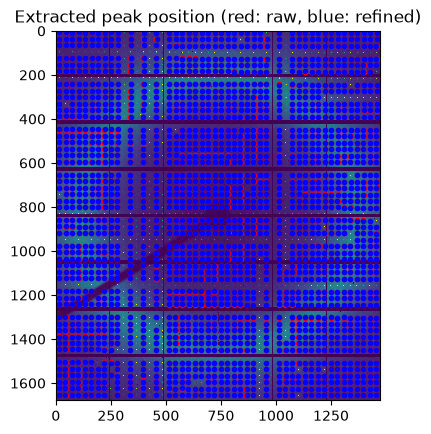

In [22]:
# Finally the peak positions are interpolated using a second order taylor expansion 
# in thevinicy of the maximum value of the signal:

#Create bilinear interpolator
bl = Bilinear(my_smooth)

#Overlay raw peak coordinate and refined peak positions

ref_peaks = [bl.local_maxi(p) for p in peaks]
fig, ax = subplots()
ax.imshow(img.clip(0,1000), interpolation="nearest")
peaks_ref = numpy.array(ref_peaks)
ax.plot(peaks_raw[:,1], peaks_raw[:, 0], ".r")
ax.plot(peaks_ref[:,1],peaks_ref[:, 0], ".b")
ax.set_title("Extracted peak position (red: raw, blue: refined)")
print("Refined peak coordinate:")
print(ref_peaks[:10])

At this stage we have about 2000 peaks (with sub-pixel precision) which are visually distributed on all modules.
Some modules have their peaks located along sub-module boundaries which are masked out, hence they have fewer control points for the calculation.
Let's assign each peak to a module identifier. This allows to print out the number of peaks per module:

In [23]:
yxi = numpy.array([i+(mid[round(i[0]),round(i[1])],) 
                   for i in ref_peaks], dtype=dt)
print("Number of keypoint per module:")
for i in range(1,mid.max()+1):
    print("Module id:",i, "cp:", (yxi[:]["i"] == i).sum())

Number of keypoint per module:
Module id: 1 cp: 48
Module id: 2 cp: 30
Module id: 3 cp: 48
Module id: 4 cp: 46
Module id: 5 cp: 42
Module id: 6 cp: 47
Module id: 7 cp: 47
Module id: 8 cp: 30
Module id: 9 cp: 48
Module id: 10 cp: 48
Module id: 11 cp: 41
Module id: 12 cp: 39
Module id: 13 cp: 48
Module id: 14 cp: 30
Module id: 15 cp: 47
Module id: 16 cp: 48
Module id: 17 cp: 42
Module id: 18 cp: 48
Module id: 19 cp: 47
Module id: 20 cp: 30
Module id: 21 cp: 48
Module id: 22 cp: 47
Module id: 23 cp: 42
Module id: 24 cp: 47
Module id: 25 cp: 48
Module id: 26 cp: 30
Module id: 27 cp: 48
Module id: 28 cp: 47
Module id: 29 cp: 41
Module id: 30 cp: 50
Module id: 31 cp: 46
Module id: 32 cp: 30
Module id: 33 cp: 48
Module id: 34 cp: 42
Module id: 35 cp: 47
Module id: 36 cp: 48
Module id: 37 cp: 48
Module id: 38 cp: 28
Module id: 39 cp: 48
Module id: 40 cp: 42
Module id: 41 cp: 44
Module id: 42 cp: 48
Module id: 43 cp: 47
Module id: 44 cp: 26
Module id: 45 cp: 46
Module id: 46 cp: 42
Module id: 4

## Grid assignment

The calibration is performed using a regular grid, the idea is to assign to each peak of coordinates (x,y) the integer value (X, Y) which correspond to the grid coordinate system. 

The first step is to measure the grid pitch which correspond to the distance (in pixels) from one peak to the next. This is easily obtained from a pair-wise distribution function.

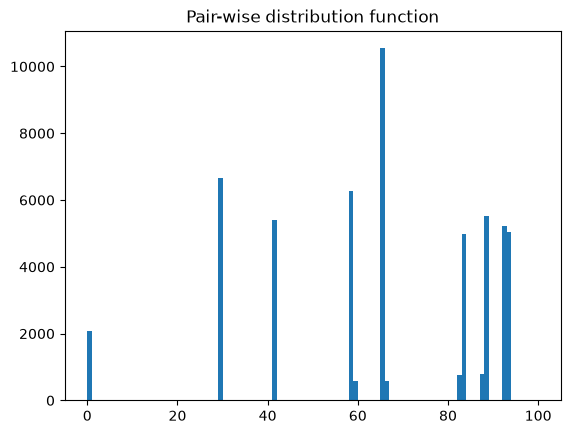

In [24]:
# pairwise distance calculation using scipy.spatial.distance_matrix

dist = distance_matrix(peaks_ref, peaks_ref)

fig, ax = subplots()
ax.hist(dist.ravel(), 100, range=(0,100))
ax.set_title("Pair-wise distribution function");

The histogram of the pair-distribution function has a first peak at 0 and the second peak between 29 and 30. 
Let's start the fit with this value

Two other parameters correspond to the offset, in pixel for the grid index (X,Y) = (0,0). 
The easiest is to measure the smallest *x* and *y* for the first module.

In [25]:
#from pair-wise distribution histogram
step = 29 
#work with the first module and fit the peak positions
first = yxi[yxi[:]["i"] == 1]
y_min = first[:]["y"].min()
x_min = first[:]["x"].min()
print("offset for the first peak: ", x_min, y_min)

offset for the first peak:  16.269793540239334 7.186804354190826


The grid looks very well aligned with the axes which makes this step easier but nothing guarantees it is perfect, so the rotation of the grid has to be measured as well.

The default rotation will be zero and will be fitted later on.

Once the indexes *X,Y* determined for each peak, one can fit the parameter to properly align the grid with the first module. Those 4 parameters are *step-size, x_min, y_min* and *angle*

In [26]:
#Assign each peak to an index
indexed1 = numpy.zeros(len(first), dtype=dl)

for i,v in enumerate(first):
    Y = int(round((v["y"]-y_min)/step))
    X = int(round((v["x"]-x_min)/step))
    indexed1[i]["y"] = v["y"]
    indexed1[i]["x"] = v["x"]
    indexed1[i]["i"] = v["i"]
    indexed1[i]["Y"] = Y
    indexed1[i]["X"] = X
    print("peak id: %s %20s Y:%d (Δ=%.3f) X:%s (Δ=%.3f)"%
          (i,v, Y, (v["y"]-Y*step-y_min)/step, X, (v["x"]-X*step-x_min)/step))


peak id: 0 (7.186804354190826, 16.41273033618927, 1) Y:0 (Δ=0.000) X:0 (Δ=0.005)
peak id: 1 (7.231230393052101, 45.745011150836945, 1) Y:0 (Δ=0.002) X:1 (Δ=0.016)
peak id: 2 (7.290591448545456, 75.19019249081612, 1) Y:0 (Δ=0.004) X:2 (Δ=0.032)
peak id: 3 (7.198769122362137, 104.56766724586487, 1) Y:0 (Δ=0.000) X:3 (Δ=0.045)
peak id: 4 (7.283639132976532, 134.01557774748653, 1) Y:0 (Δ=0.003) X:4 (Δ=0.060)
peak id: 5 (7.254908889532089, 163.38282072544098, 1) Y:0 (Δ=0.002) X:5 (Δ=0.073)
peak id: 6 (7.367172479629517, 192.76562055945396, 1) Y:0 (Δ=0.006) X:6 (Δ=0.086)
peak id: 7 (7.374693810939789, 222.16684445738792, 1) Y:0 (Δ=0.006) X:7 (Δ=0.100)
peak id: 8 (154.25518941879272, 16.269793540239334, 1) Y:5 (Δ=0.071) X:0 (Δ=0.000)
peak id: 9 (154.21079713106155, 45.57556250691414, 1) Y:5 (Δ=0.070) X:1 (Δ=0.011)
peak id: 10 (154.28871083259583, 75.04928851872683, 1) Y:5 (Δ=0.072) X:2 (Δ=0.027)
peak id: 11 (154.2160492092371, 104.43665820360184, 1) Y:5 (Δ=0.070) X:3 (Δ=0.040)
peak id: 12 (15

The error in positioning each of the pixels is less than 0.1 pixel which is already excellent and will allow a straightforward fit.

The cost function for the first module is calculated as the sum of distances squared in pixel space.
It uses 4 parameters which are step-size, x_min, y_min and angle

In [27]:
#Calculate the center of every single module for rotation around this center.
centers = {i: numpy.array([[numpy.where(mid == i)[1].mean()], [numpy.where(mid == i)[0].mean()]]) for i in range(1, 49)}
for k,v in centers.items():
    print(k,v.ravel())

1 [121.  97.]
2 [364.5  97. ]
3 [615.  97.]
4 [858.5  97. ]
5 [1109.   97.]
6 [1352.5   97. ]
7 [121. 309.]
8 [364.5 309. ]
9 [615. 309.]
10 [858.5 309. ]
11 [1109.  309.]
12 [1352.5  309. ]
13 [121. 521.]
14 [364.5 521. ]
15 [615. 521.]
16 [858.5 521. ]
17 [1109.  521.]
18 [1352.5  521. ]
19 [121. 733.]
20 [364.5 733. ]
21 [615. 733.]
22 [858.5 733. ]
23 [1109.  733.]
24 [1352.5  733. ]
25 [121. 945.]
26 [364.5 945. ]
27 [615. 945.]
28 [858.5 945. ]
29 [1109.  945.]
30 [1352.5  945. ]
31 [ 121. 1157.]
32 [ 364.5 1157. ]
33 [ 615. 1157.]
34 [ 858.5 1157. ]
35 [1109. 1157.]
36 [1352.5 1157. ]
37 [ 121. 1369.]
38 [ 364.5 1369. ]
39 [ 615. 1369.]
40 [ 858.5 1369. ]
41 [1109. 1369.]
42 [1352.5 1369. ]
43 [ 121. 1581.]
44 [ 364.5 1581. ]
45 [ 615. 1581.]
46 [ 858.5 1581. ]
47 [1109. 1581.]
48 [1352.5 1581. ]


In [28]:
# Define a rotation of a module around the center of the module ...

def rotate(angle, xy, module):
    "Perform the rotation of the xy points around the center of the given module"
    rot = [[cos(angle),-sin(angle)],
           [sin(angle), cos(angle)]]
    center = centers[module]
    return numpy.dot(rot, xy - center) + center

In [29]:
guess1 = [step, y_min, x_min, 0]

def cost1(param):
    """contains: step, y_min, x_min, angle for the first module
    returns the sum of distance squared in pixel space
    """
    step = param[0]
    y_min = param[1]
    x_min = param[2]
    angle = param[3]
    XY = numpy.vstack((indexed1["X"], indexed1["Y"]))
#     rot = [[cos(angle),-sin(angle)],
#            [sin(angle), cos(angle)]]
    xy_min = [[x_min], [y_min]]
    xy_guess = rotate(angle, step * XY + xy_min, module=1)
    delta = xy_guess - numpy.vstack((indexed1["x"], indexed1["y"]))
    return (delta*delta).sum()

In [30]:
print("Before optimization", guess1, "cost=", cost1(guess1))
res1 = minimize(cost1, guess1, method = "slsqp")
print(res1)
print("After optimization", res1.x, "cost=", cost1(res1.x))
print("Average displacement (pixels): ",sqrt(cost1(res1.x)/len(indexed1)))

Before optimization [29, np.float64(7.186804354190826), np.float64(16.269793540239334), 0] cost= 250.36710826038234
     message: Optimization terminated successfully
     success: True
      status: 0
         fun: 0.633754194771643
           x: [ 2.940e+01  7.242e+00  1.631e+01  8.769e-04]
         nit: 8
         jac: [-1.575e-05 -5.364e-07  4.545e-07  8.901e-04]
        nfev: 54
        njev: 8
 multipliers: []
After optimization [2.93980816e+01 7.24220066e+00 1.63128834e+01 8.76927128e-04] cost= 0.633754194771643
Average displacement (pixels):  0.11490523221801476


At this step, the grid is perfectly aligned with the first module. 
This module is used as the reference one and all other are aligned along it, using this first fit:

In [31]:
#retrieve the result of the first module fit:
step, y_min, x_min, angle = res1.x
indexed = numpy.zeros(yxi.shape, dtype=dl)

# rot =  [[cos(angle),-sin(angle)],
#         [sin(angle), cos(angle)]]
# irot =  [[cos(angle), sin(angle)],
#          [-sin(angle), cos(angle)]]

print("cost1: ",cost1([step, y_min, x_min, angle]), "for:", step, y_min, x_min, angle)

xy_min = numpy.array([[x_min], [y_min]])
xy = numpy.vstack((yxi["x"], yxi["y"]))
indexed["y"] = yxi["y"]
indexed["x"] = yxi["x"]
indexed["i"] = yxi["i"]
XY_app = (rotate(-angle, xy, 1)-xy_min) / step
XY_int = numpy.round((XY_app)).astype("int")
indexed["X"] = XY_int[0]
indexed["Y"] = XY_int[1]
xy_guess = rotate(angle, step * XY_int + xy_min, 1)

thres = 1.2
delta = abs(xy_guess - xy)
print((delta>thres).sum(), "suspicious peaks:")
suspicious = indexed[numpy.where(abs(delta>thres))[1]]
print(suspicious)

cost1:  0.633754194771643 for: 29.3980815979019 7.242200662469269 16.312883389140723 0.0008769271280303839
6 suspicious peaks:
[(1595.5792897 , 954.49445057, 46, 54, 32)
 (1448.30209509, 748.8784325 , 40, 49, 25)
 (1448.66381988, 895.86545633, 40, 49, 30)
 (1448.84506877, 954.56920397, 40, 49, 32)
 (1624.68617365, 807.47743243, 46, 55, 27)
 (1654.4202804 , 954.44135761, 46, 56, 32)]


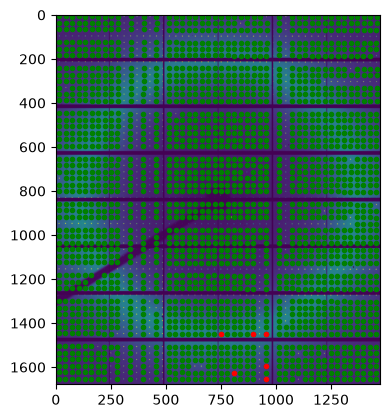

In [32]:
fig,ax = subplots()
ax.imshow(img.clip(0,1000))
ax.plot(indexed["x"], indexed["y"],".g")
ax.plot(suspicious["x"], suspicious["y"],".r")
pass

Only 6 peaks have an initial displacement of more than 1.2 pixel, all located in modules 40 and 46. 
The visual inspection confirms their localization is valid.

There are 48 (half-)modules which have each of them 2 translations and one rotation. 
In addition to the step size, this represents 145 degrees of freedom for the fit.
The first module is used to align the grid, all other modules are then aligned along this grid.

In [33]:
def submodule_cost(param, module=1):
    """contains: step, y_min_1, x_min_1, angle_1, y_min_2, x_min_2, angle_2, ...
    returns the sum of distance squared in pixel space
    """
    
    step = param[0]
    y_min1 = param[1]
    x_min1 = param[2]
    angle1 = param[3]
    
    mask = indexed["i"] == module
    substack = indexed[mask]
    
    XY = numpy.vstack((substack["X"], substack["Y"]))
#     rot1 = [[cos(angle1), -sin(angle1)],
#             [sin(angle1), cos(angle1)]]
    xy_min1 = numpy.array([[x_min1], [y_min1]])
    xy_guess1 = rotate(angle1, step * XY + xy_min1, module=1)
    #This is guessed spot position for module #1
    if module == 1:
        "Not much to do for module 1"
        delta = xy_guess1 - numpy.vstack((substack["x"], substack["y"]))
    else:
        "perform the correction for given module"
        y_min = param[(module-1)*3+1]
        x_min = param[(module-1)*3+2]
        angle = param[(module-1)*3+3]     

#         rot = numpy.array([[cos(angle),-sin(angle)],
#                            [sin(angle), cos(angle)]])
        xy_min = numpy.array([[x_min], [y_min]])
        xy_guess = rotate(angle, xy_guess1+xy_min, module)
        delta = xy_guess - numpy.vstack((substack["x"], substack["y"]))

    return (delta*delta).sum()

guess145 = numpy.zeros(48*3+1)
guess145[:4] = res1.x
for i in range(1, 49):
    print("Cost for module #",i, submodule_cost(guess145, i))


Cost for module # 1 0.633754194771643
Cost for module # 2 1.8140315285773634
Cost for module # 3 1.850856256527353
Cost for module # 4 4.910327008006769
Cost for module # 5 1.774873751431033
Cost for module # 6 7.482506433765246
Cost for module # 7 14.440093179922567
Cost for module # 8 5.219966483260526
Cost for module # 9 23.407231018662827
Cost for module # 10 5.689978445457244
Cost for module # 11 4.125578726571817
Cost for module # 12 8.410831808440108
Cost for module # 13 29.859818004840907
Cost for module # 14 12.628450441953628
Cost for module # 15 3.1377072711480474
Cost for module # 16 5.277307799112051
Cost for module # 17 8.497321083134151
Cost for module # 18 4.653144928284347
Cost for module # 19 6.007093478206573
Cost for module # 20 4.980266640652358
Cost for module # 21 5.136963455482422
Cost for module # 22 5.048718212080771
Cost for module # 23 1.4373135460395552
Cost for module # 24 6.0462944176158
Cost for module # 25 38.25446293029344
Cost for module # 26 19.50979

One retrieves that the modules 40 and 46 have large errors. Module 37 as well.

The total cost function is hence the sum of all cost functions for all modules:

In [34]:
def total_cost(param):
    """contains: step, y_min_1, x_min_1, angle_1, ...
    returns the sum of distance squared in pixel space
    """
    return sum(submodule_cost(param, module=i) for i in range(1,49))
total_cost(guess145)

np.float64(778.3947880884217)

In [35]:
%%time
print("Before optimization", guess145[:10], "cost=", total_cost(guess145))
res_all = minimize(total_cost, guess145, method = "slsqp")
print(res_all)
print("After optimization", res_all.x[:10], "cost=", total_cost(res_all.x))

Before optimization [2.93980816e+01 7.24220066e+00 1.63128834e+01 8.76927128e-04
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00] cost= 778.3947880884217
     message: Optimization terminated successfully
     success: True
      status: 0
         fun: 27.18456682321919
           x: [ 2.941e+01  7.212e+00 ... -9.241e-01  1.891e-03]
         nit: 89
         jac: [-1.679e+00 -2.259e-02 ... -7.662e-03  3.873e-03]
        nfev: 13373
        njev: 89
 multipliers: []
After optimization [ 2.94082824e+01  7.21154026e+00  1.62772326e+01  8.29087331e-04
 -1.49122457e-01 -1.98981521e-01  3.22831992e-04  1.25938709e-01
 -2.38719352e-01  9.70959844e-04] cost= 27.18456682321919
CPU times: user 7min 54s, sys: 550 ms, total: 7min 54s
Wall time: 25 s


In [36]:
for i in range(1,49):
    print("Module id: %d cost: %.3f Δx: %.3f, Δy: %.3f rot: %.3f°"%
          (i, submodule_cost(res_all.x, i), res_all.x[-2+i*3], res_all.x[-1+i*3], numpy.rad2deg(res_all.x[i*3])))

Module id: 1 cost: 0.684 Δx: 7.212, Δy: 16.277 rot: 0.048°
Module id: 2 cost: 0.473 Δx: -0.149, Δy: -0.199 rot: 0.018°
Module id: 3 cost: 0.650 Δx: 0.126, Δy: -0.239 rot: 0.056°
Module id: 4 cost: 0.613 Δx: 0.290, Δy: -0.226 rot: 0.114°
Module id: 5 cost: 0.566 Δx: -0.075, Δy: -0.465 rot: 0.021°
Module id: 6 cost: 0.666 Δx: 0.316, Δy: -0.641 rot: 0.122°
Module id: 7 cost: 0.696 Δx: -0.599, Δy: 0.075 rot: 0.080°
Module id: 8 cost: 0.341 Δx: -0.429, Δy: -0.134 rot: 0.065°
Module id: 9 cost: 0.566 Δx: -0.699, Δy: -0.414 rot: 0.054°
Module id: 10 cost: 0.661 Δx: -0.210, Δy: -0.454 rot: 0.123°
Module id: 11 cost: 0.616 Δx: 0.237, Δy: -0.266 rot: 0.030°
Module id: 12 cost: 0.495 Δx: 0.344, Δy: -0.172 rot: 0.040°
Module id: 13 cost: 0.763 Δx: -0.685, Δy: -0.571 rot: 0.068°
Module id: 14 cost: 0.353 Δx: -0.510, Δy: -0.583 rot: 0.078°
Module id: 15 cost: 0.645 Δx: -0.289, Δy: -0.334 rot: 0.058°
Module id: 16 cost: 0.492 Δx: -0.018, Δy: -0.555 rot: 0.076°
Module id: 17 cost: 0.440 Δx: -0.295, Δy

Analysis:
Modules 40, 46 and 48 show large displacement but the fitting procedure allowed to reduce the residual cost to the same value as other modules.

## Reconstruction of the pixel position

The pixel position can be obtained from the *standard* Pilatus detector. 
Each module is then displaced according to the fitted values, except the first one which is left where it is.

In [37]:
def correct(x, y, dx, dy, angle, module):
    "apply the correction dx, dy and angle to those pixels ..."
    trans = numpy.array([[dx],
                         [dy]])
    xy_guess = numpy.vstack((x.ravel(), 
                             y.ravel()))
    xy_cor = rotate(-angle, xy_guess, module) - trans
    xy_cor.shape = ((2,)+x.shape)
    return xy_cor[0], xy_cor[1]

In [38]:
pixel_coord = pyFAI.detector_factory("Pilatus2MCdTe").get_pixel_corners()
pixel_coord_raw = pixel_coord.copy()
for i in range(2, 49):
    # Extract the pixel corners for one module
    module_idx = numpy.where(mid == i)
    one_module = pixel_coord_raw[module_idx]
    #retrieve the fitted values
    dy, dx, angle = res_all.x[-2+i*3:1+3*i]
    
    y = one_module[..., 1]/pilatus.pixel1
    x = one_module[..., 2]/pilatus.pixel2
    
    #apply the correction the other way around
    x_cor, y_cor = correct(x, y, dx, dy, angle, i)
    one_module[...,1] = y_cor * pilatus.pixel1 #y
    one_module[...,2] = x_cor * pilatus.pixel2 #x
    #Update the array
    pixel_coord_raw[module_idx] = one_module


/tmp/ipykernel_266265/754752315.py:8: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  xy_cor.shape = ((2,)+x.shape)


## Update the detector and save it in HDF5

In [39]:
pilatus.set_pixel_corners(pixel_coord_raw)
pilatus.mask = all_masks
pilatus.save("Pilatus_ID15_raw.h5")

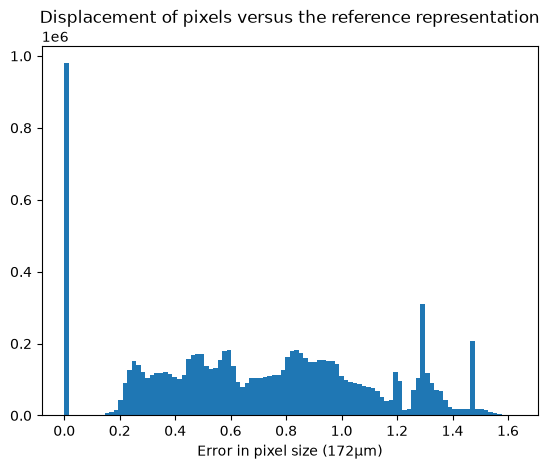

In [40]:
displ = numpy.sqrt(((pixel_coord - pixel_coord_raw)**2).sum(axis=-1))
displ /= pilatus.pixel1 #convert in pixel units
fig, ax = subplots()
ax.hist(displ.ravel(), 100)
ax.set_title("Displacement of pixels versus the reference representation")
ax.set_xlabel("Error in pixel size (172µm)")
pass

In [41]:
misaligned = numpy.vstack((pixel_coord_raw[..., 2].ravel(), #x
                           pixel_coord_raw[..., 1].ravel())) #y

reference = numpy.vstack((pixel_coord[..., 2].ravel(), #x
                          pixel_coord[..., 1].ravel())) #y

In [42]:
#Kabsch alignment of the whole detector ... 

def kabsch(P, R):
    "Align P on R"
    centroid_P = P.mean(axis=0)
    centroid_R = R.mean(axis=0)
    centered_P = P - centroid_P
    centered_R = R - centroid_R
    C = numpy.dot(centered_P.T, centered_R)
    V, S, W = numpy.linalg.svd(C)
    d = (numpy.linalg.det(V) * numpy.linalg.det(W)) < 0.0
    if d:
        S[-1] = -S[-1]
        V[:, -1] = -V[:, -1]
    # Create Rotation matrix U
    U = numpy.dot(V, W)
    P = numpy.dot(centered_P, U)
    return P + centroid_R
    
%time aligned = kabsch(misaligned.T, reference.T).T

CPU times: user 6.29 s, sys: 201 ms, total: 6.49 s
Wall time: 198 ms


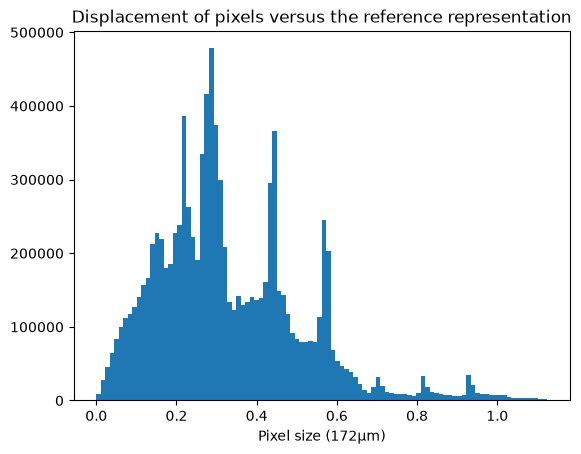

In [43]:
displ = numpy.sqrt(((aligned-reference)**2).sum(axis=0))
displ /= pilatus.pixel1 #convert in pixel units
fig, ax = subplots()
ax.hist(displ.ravel(), 100)
ax.set_title("Displacement of pixels versus the reference representation")
ax.set_xlabel("Pixel size (172µm)")
pass

In [44]:
pixel_coord_aligned = pixel_coord.copy()
pixel_coord_aligned[...,1] = aligned[1,:].reshape(pixel_coord.shape[:-1])
pixel_coord_aligned[...,2] = aligned[0,:].reshape(pixel_coord.shape[:-1])

pilatus.set_pixel_corners(pixel_coord_aligned)
pilatus.mask = all_masks
pilatus.save("Pilatus_ID15_Kabsch.h5")

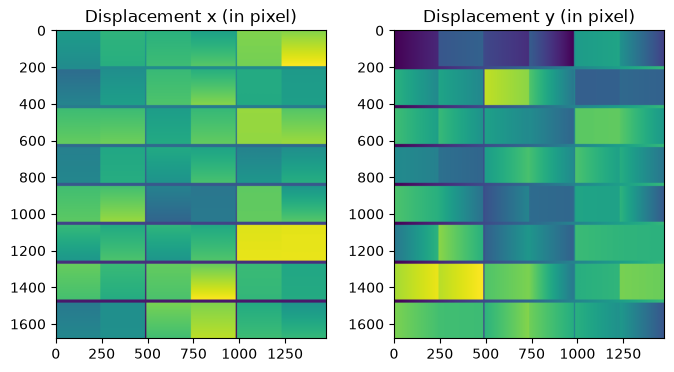

In [45]:
fig, ax = subplots(1, 2, figsize=(8, 4))
ax[0].imshow((pixel_coord_aligned[...,2].mean(axis=-1) - pixel_coord[...,2].mean(axis=-1))/pilatus.pixel2)
ax[0].set_title("Displacement x (in pixel)")
ax[1].imshow((pixel_coord_aligned[...,1].mean(axis=-1) - pixel_coord[...,1].mean(axis=-1))/pilatus.pixel1)
ax[1].set_title("Displacement y (in pixel)")
pass

## Validation of the result

To validate the improvement obtained, one can perform the experiment calibration and the 2D integration of a reference compound, the 2D integration with either the reference from Dectris or this freshly refined detector.



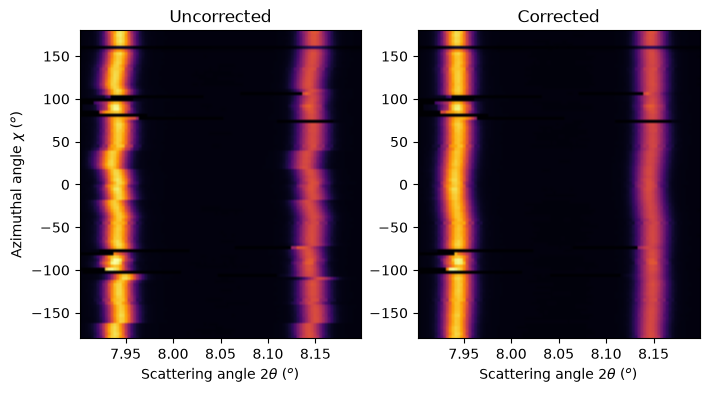

In [46]:
# The geometry has been obtained from pyFAI
geo = { "dist":  0.8001094657585498,
        "poni1": 0.14397714477803805,
        "poni2": 0.12758748978422835,
        "rot1":  0.0011165686147339689,
        "rot2":  0.0002214091645638961,
        "rot3":  0,
        "detector": "Pilatus2MCdTe"}
ai_unc = AzimuthalIntegrator(**geo)
geo["detector"] = "Pilatus_ID15_Kabsch.h5"
ai_cor = AzimuthalIntegrator(**geo)
fig, ax = subplots(1, 2, figsize=(8,4))
method = ("pseudo", "histogram", "cython")
res_unc = ai_unc.integrate2d_ng(rings, 100, 100, radial_range=(7.9, 8.2), unit="2th_deg", method=method, mask=all_masks)
res_cor = ai_cor.integrate2d_ng(rings, 100, 100, radial_range=(7.9, 8.2), unit="2th_deg", method=method, mask=all_masks)
opts = {"origin":"lower",
        "extent": [res_unc.radial.min(), res_unc.radial.max(), -180, 180], 
        "aspect":"auto",
        "cmap":"inferno"}
ax[0].imshow(res_unc[0], **opts)
ax[1].imshow(res_cor[0], **opts)
ax[0].set_xlabel(r"Scattering angle 2$\theta$ ($^{o}$)")
ax[1].set_xlabel(r"Scattering angle 2$\theta$ ($^{o}$)")
ax[0].set_ylabel(r"Azimuthal angle $\chi$ ($^{o}$)")
ax[0].set_title("Uncorrected")
ax[1].set_title("Corrected")
pass

## Conclusion

This tutorial presents the way to calibrate a module based detector using the Pilatus2M CdTe from ESRF-ID15.
The HDF5 file generated is directly usable by any parts of pyFAI, the reader is invited in calibrating the rings images with the default definition and with this optimized definition and check the residual error is almost divided by a factor two.

To come back on the precision of the localization of the pixel: not all the pixels are within the specifications provided by Dectris which claims the misalignment of the modules is within one pixel.


In [47]:
print(f"Total execution time: {time.perf_counter()-start_time:.3f}s")

Total execution time: 54.948s
